# Bone Forensics Siamese LeNet Evaluation

Evaluate an already trained `siamese-le-net` checkpoint on the test split, then render GradCAM, AblationCAM, and ScoreCAM views for sampled one-shot test pairs.

In [1]:
from pathlib import Path
import base64
from io import BytesIO
import sys

import numpy as np
import csv
import torch
from IPython.display import HTML, display
from PIL import Image, ImageDraw

REPO_DIR = Path("/home/ralampay/workspace/mlx")
DATASET_DIR = Path(
    "/home/ralampay/Desktop/tmp/test/one-shot-experiment/"
    "bone-forensics-experiment/bone-forensics-one-shot-01"
)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

MODEL_NAME = "siamese-le-net"
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

RUN_NAME = f"bone-forensics-{MODEL_NAME}-{SEED}"
ARTIFACTS_DIR = REPO_DIR / "tmp" / "artifacts" / RUN_NAME
BENCHMARK_DIR = REPO_DIR / "tmp" / "benchmark" / RUN_NAME
CHECKPOINT_PATH = ARTIFACTS_DIR / f"{MODEL_NAME}.pth"
CAM_OUTPUT_DIR = BENCHMARK_DIR / "cam"

BATCH_SIZE = 8
NUM_PAIRS = 100
CAM_NUM_PAIRS = 20
CAM_MAX_PAIRS = 6
CAM_METHODS = ["gradcam", "ablationcam", "scorecam"]

print("device:", DEVICE)
print("dataset:", DATASET_DIR)
print("checkpoint:", CHECKPOINT_PATH)
print("cam output:", CAM_OUTPUT_DIR)

device: cpu
dataset: /home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01
checkpoint: /home/ralampay/workspace/mlx/tmp/artifacts/bone-forensics-siamese-le-net-42/siamese-le-net.pth
cam output: /home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42/cam


In [2]:
assert DATASET_DIR.exists(), f"Dataset directory not found: {DATASET_DIR}"
assert (DATASET_DIR / "test").exists(), f"Test split not found: {DATASET_DIR / 'test'}"
assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"

CAM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for split in ["train", "val", "test"]:
    split_dir = DATASET_DIR / split
    labels = sorted(path.name for path in split_dir.iterdir() if path.is_dir()) if split_dir.exists() else []
    print(f"{split}: {len(labels)} labels -> {labels}")

train: 7 labels -> ['1', '10', '3', '4', '6', '7', '8']
val: 7 labels -> ['1', '10', '3', '4', '6', '7', '8']
test: 7 labels -> ['1', '10', '3', '4', '6', '7', '8']


## Benchmark the Test Split

This uses the project benchmark operation against the trained checkpoint. For one-shot models, benchmark creates deterministic positive and negative test pairs, reports pair-verification metrics, and writes CSV/plot artifacts under `BENCHMARK_DIR`.

In [3]:
from mlx.modes.image_classification.evaluation import benchmark_image_classification

test_config = {
    "model": MODEL_NAME,
    "dataset_path": str(DATASET_DIR),
    "model_path": str(CHECKPOINT_PATH),
    "output_path": str(BENCHMARK_DIR),
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "num_pairs": NUM_PAIRS,
    "random_seed": SEED,
}

test_metrics = benchmark_image_classification(test_config)
test_metrics

Skipping label '4' for one-shot benchmark because it has fewer than two images.

Loaded 600 deterministic one-shot benchmark pairs from 
/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test

Evaluating pairs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:48<00:00,  1.54it/s]


Skipping label '4' for one-shot benchmark because it has fewer than two images.

Evaluating N-way queries: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:16<00:00,  1.10it/s]


...

   One-Shot Pair Verification    
             Results             
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric               ┃  Score ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Accuracy             │ 0.8233 │
│ Ave Precision        │ 0.8235 │
│ Ave Recall           │ 0.8233 │
│ F1-score             │ 0.8233 │
│ ROC AUC (macro)      │ 0.8771 │
│ Average Precision    │ 0.8508 │
│ Equal Error Rate     │ 0.1733 │
│ Best F1 Threshold    │ 0.4854 │
└──────────────────────┴────────┘

                Per-Class Metrics                 
┏━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Class     ┃    AUC ┃ Sensitivity ┃ Specificity ┃
┡━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ different │ 0.8771 │      0.8133 │      0.8333 │
│ same      │ 0.8771 │      0.8333 │      0.8133 │
└───────────┴────────┴─────────────┴─────────────┘

Benchmark artifacts written to /home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42

One-shot research artifacts written to /home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42

{'accuracy': 0.8233333333333334,
 'precision': 0.8234627184207016,
 'recall': 0.8233333333333334,
 'f1': 0.8233156648998233,
 'avg_precision': 0.8234627184207016,
 'avg_recall': 0.8233333333333334,
 'sensitivity_different': 0.8133333333333334,
 'specificity_different': 0.8333333333333334,
 'sensitivity_same': 0.8333333333333334,
 'specificity_same': 0.8133333333333334,
 'roc_auc_macro_ovr': 0.8771222222222222,
 'auc_different': 0.8771222222222222,
 'auc_same': 0.8771222222222222,
 'average_precision': 0.8508346257173758,
 'equal_error_rate': 0.1733333333333333,
 'equal_error_rate_threshold': 0.5009515285491943,
 'best_f1': 0.841091492776886,
 'best_f1_threshold': 0.48536697030067444,
 'best_f1_accuracy': 0.835,
 'best_youden_j': 0.6699999999999999,
 'best_youden_threshold': 0.48536697030067444,
 'best_youden_accuracy': 0.835,
 'n_way_accuracy': 0.4444444444444444,
 'n_way_precision': 0.39999999999999997,
 'n_way_recall': 0.4444444444444444,
 'n_way_f1': 0.41190476190476183}

In [4]:
metrics_path = BENCHMARK_DIR / "metrics.csv"
pair_predictions_path = BENCHMARK_DIR / "pair_predictions.csv"

def read_csv_rows(path, limit=None):
    with path.open(newline="", encoding="utf-8") as csv_file:
        rows = list(csv.DictReader(csv_file))
    return rows[:limit] if limit is not None else rows

def display_records(records, title):
    if not records:
        print(f"No rows to display for {title}")
        return
    headers = list(records[0].keys())
    html = f"<h4>{title}</h4><table style='border-collapse:collapse;width:100%'>"
    html += "<tr>" + "".join(f"<th style='border:1px solid #cfd8e3;padding:6px;text-align:left'>{header}</th>" for header in headers) + "</tr>"
    for record in records:
        html += "<tr>" + "".join(f"<td style='border:1px solid #cfd8e3;padding:6px'>{record.get(header, '')}</td>" for header in headers) + "</tr>"
    html += "</table>"
    display(HTML(html))

if metrics_path.exists():
    display_records(read_csv_rows(metrics_path), "Metrics")

if pair_predictions_path.exists():
    pair_predictions = read_csv_rows(pair_predictions_path)
    display_records(pair_predictions[:10], "Pair predictions preview")
else:
    pair_predictions = None

metric,value
accuracy,0.823333
auc_different,0.877122
auc_same,0.877122
average_precision,0.850835
avg_precision,0.823463
avg_recall,0.823333
best_f1,0.841091
best_f1_accuracy,0.835000
best_f1_threshold,0.485367
best_youden_accuracy,0.835000


pair_id,image_1,label_1,image_2,label_2,target,predicted,same_probability
1,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/8/DSCN9314.JPG,8,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/3/DSCN9104.JPG,3,0,0,0.12063591
2,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/1/DSCN8988.JPG,1,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/1/DSCN8959.JPG,1,1,1,0.55276972
3,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/6/DSCN9033.JPG,6,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/7/DSCN9246.JPG,7,0,1,0.58908254
4,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/1/DSCN8988.JPG,1,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/1/DSCN8989.JPG,1,1,1,0.50412971
5,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/3/DSCN9104.JPG,3,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/6/DSCN9033.JPG,6,0,0,0.48403677
6,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/8/DSCN9363.JPG,8,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/8/DSCN9372.JPG,8,1,1,0.55158973
7,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/3/DSCN9104.JPG,3,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/3/DSCN9127.JPG,3,1,1,0.50095153
8,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/3/DSCN9104.JPG,3,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/3/DSCN9127.JPG,3,1,1,0.50095153
9,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/1/DSCN8959.JPG,1,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/1/DSCN8988.JPG,1,1,1,0.55276972
10,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/8/DSCN9314.JPG,8,/home/ralampay/Desktop/tmp/test/one-shot-experiment/bone-forensics-experiment/bone-forensics-one-shot-01/test/8/DSCN9363.JPG,8,1,1,0.51475877


## Generate GradCAM, AblationCAM, and ScoreCAM

The notebook calls the library CAM operation once per method with `display=False`, so results are returned as Python objects and saved under `CAM_OUTPUT_DIR` instead of being shown in OpenCV windows.

In [5]:
from mlx.modes.image_classification.cam import generate_image_classification_cams

cam_results_by_method = {}

for method in CAM_METHODS:
    print(f"Generating {method}...")
    cam_results_by_method[method] = generate_image_classification_cams({
        "model": MODEL_NAME,
        "model_path": str(CHECKPOINT_PATH),
        "dataset_path": str(DATASET_DIR),
        "output_path": str(CAM_OUTPUT_DIR / method),
        "device": DEVICE,
        "cam_method": method,
        "num_pairs": CAM_NUM_PAIRS,
        "max_samples": CAM_MAX_PAIRS,
        "display": False,
        "save_images": True,
        "random_seed": SEED,
    })

{method: len(results) for method, results in cam_results_by_method.items()}

Generating gradcam...


Skipping label '4' for one-shot benchmark because it has fewer than two images.

Wrote 
/home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42/cam/gradcam/8-DSCN9314-gradcam-pair0001
-a-different.png

Wrote 
/home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42/cam/gradcam/6-DSCN9033-gradcam-pair0001
-b-different.png

Wrote 
/home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42/cam/gradcam/1-DSCN8959-gradcam-pair0002
-a-same.png

...

Wrote 
/home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42/cam/scorecam/10-DSCN9400-scorecam-pair0
006-a-same.png

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:04<00:00,  3.65it/s]


Wrote 
/home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42/cam/scorecam/10-DSCN9423-scorecam-pair0
006-b-same.png

Generated 12 CAM image(s)

{'gradcam': 12, 'ablationcam': 12, 'scorecam': 12}

## Side-by-Side CAM Table

Each row is one sampled one-shot pair. The image column shows the explained query image beside its fixed reference image. The confidence is the model's same-class probability for that pair.

In [6]:
from mlx.modes.image_classification.data import load_image_tensor
from mlx.modes.image_classification.evaluation import _build_one_shot_benchmark_pairs
from mlx.modes.image_classification.utils import load_checkpoint_bundle

model, metadata = load_checkpoint_bundle({
    "model": MODEL_NAME,
    "model_path": str(CHECKPOINT_PATH),
    "device": DEVICE,
})
model = model.to(DEVICE).eval()

pairs = _build_one_shot_benchmark_pairs(
    DATASET_DIR / "test",
    pairs_per_class=CAM_NUM_PAIRS,
    random_seed=SEED,
)[:CAM_MAX_PAIRS]

def load_rgb_uint8(image_path):
    tensor = load_image_tensor(
        image_path,
        input_size=metadata["input_size"],
        colored=metadata["colored"],
    )
    image = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    if not metadata["colored"]:
        image = np.repeat(image, 3, axis=2)
    return (np.clip(image, 0.0, 1.0) * 255).astype(np.uint8)

def pair_probability(pair):
    image_one = load_image_tensor(
        pair.image_one,
        input_size=metadata["input_size"],
        colored=metadata["colored"],
    ).unsqueeze(0).to(DEVICE)
    image_two = load_image_tensor(
        pair.image_two,
        input_size=metadata["input_size"],
        colored=metadata["colored"],
    ).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return float(model(image_one, image_two).reshape(-1)[0].detach().cpu())

def combine_pair_images(image_one_path, image_two_path):
    left = Image.fromarray(load_rgb_uint8(image_one_path))
    right = Image.fromarray(load_rgb_uint8(image_two_path))
    gap = 8
    canvas = Image.new("RGB", (left.width + right.width + gap, max(left.height, right.height)), "white")
    canvas.paste(left, (0, 0))
    canvas.paste(right, (left.width + gap, 0))
    draw = ImageDraw.Draw(canvas)
    draw.line((left.width + gap // 2, 0, left.width + gap // 2, canvas.height), fill=(220, 220, 220), width=2)
    return np.asarray(canvas)

def image_to_data_uri(rgb_uint8):
    image = Image.fromarray(rgb_uint8)
    buffer = BytesIO()
    image.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{encoded}"

rows = []
for index, pair in enumerate(pairs):
    probability = pair_probability(pair)
    predicted = "same" if probability >= 0.5 else "different"
    expected = "same" if pair.target == 1 else "different"

    # generate_one_shot_cams emits two results per pair: side a, then side b.
    method_images = {}
    for method in CAM_METHODS:
        method_images[method] = cam_results_by_method[method][index * 2].visualization

    rows.append({
        "pair": pair,
        "expected": expected,
        "predicted": predicted,
        "confidence": probability if predicted == "same" else 1.0 - probability,
        "same_probability": probability,
        "pair_image": combine_pair_images(pair.image_one, pair.image_two),
        **method_images,
    })

len(rows)

Skipping label '4' for one-shot benchmark because it has fewer than two images.

6

Classification,Image Pair,GradCAM,AblationCAM,ScoreCAM
Expected: different Predicted: different Confidence: 0.932 Same prob: 0.068 correct left: 8/DSCN9314.JPG right: 6/DSCN9033.JPG,,,,
Expected: same Predicted: same Confidence: 0.564 Same prob: 0.564 correct left: 1/DSCN8959.JPG right: 1/DSCN8989.JPG,,,,
Expected: different Predicted: different Confidence: 0.609 Same prob: 0.391 correct left: 1/DSCN8959.JPG right: 3/DSCN9124.JPG,,,,
Expected: different Predicted: different Confidence: 0.820 Same prob: 0.180 correct left: 10/DSCN9400.JPG right: 6/DSCN9024.JPG,,,,
Expected: same Predicted: same Confidence: 0.563 Same prob: 0.563 correct left: 7/DSCN9266.JPG right: 7/DSCN9169.JPG,,,,
Expected: same Predicted: same Confidence: 0.633 Same prob: 0.633 correct left: 10/DSCN9400.JPG right: 10/DSCN9423.JPG,,,,

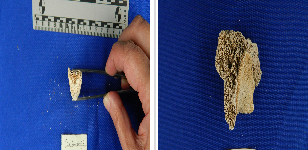
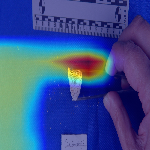
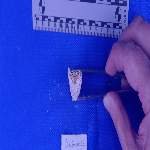
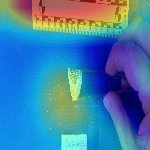
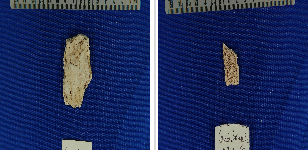
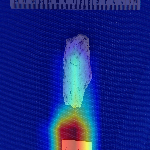
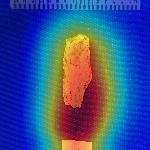
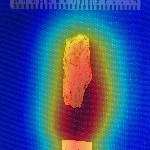
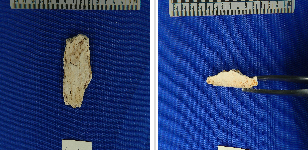
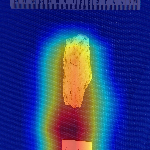
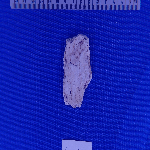
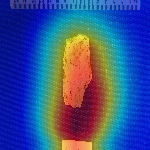
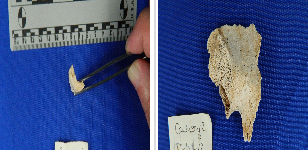
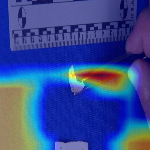
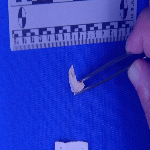
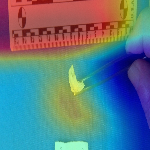
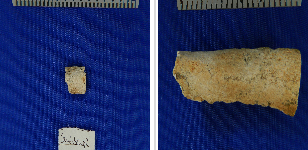
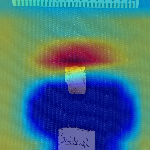
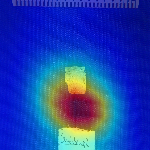
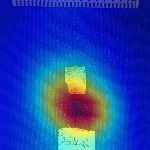
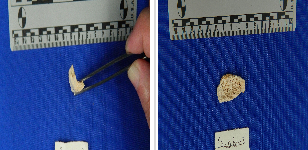
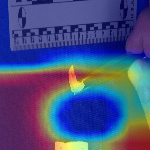
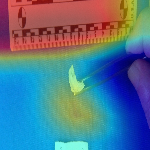
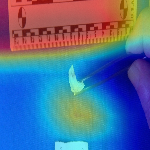

Saved CAM images under: /home/ralampay/workspace/mlx/tmp/benchmark/bone-forensics-siamese-le-net-42/cam


In [7]:
html = """
<style>
.cam-table {
    border-collapse: collapse;
    width: 100%;
    font-family: Arial, sans-serif;
}
.cam-table th, .cam-table td {
    border: 1px solid #cfd8e3;
    padding: 12px;
    text-align: center;
    vertical-align: middle;
}
.cam-table th {
    font-size: 18px;
    font-weight: 700;
}
.cam-table td.category {
    text-align: left;
    min-width: 190px;
    font-size: 14px;
}
.cam-table img {
    max-width: 230px;
    height: auto;
}
.meta {
    color: #475569;
    font-size: 12px;
    margin-top: 6px;
    line-height: 1.35;
}
</style>

<h3>Siamese LeNet: Test Pair CAM Comparison</h3>
<table class="cam-table">
<thead>
<tr>
    <th>Classification</th>
    <th>Image Pair</th>
    <th>GradCAM</th>
    <th>AblationCAM</th>
    <th>ScoreCAM</th>
</tr>
</thead>
<tbody>
"""

for row in rows:
    pair = row["pair"]
    correctness = "correct" if row["expected"] == row["predicted"] else "incorrect"
    category = f"""
    <b>Expected:</b> {row["expected"]}<br>
    <b>Predicted:</b> {row["predicted"]}<br>
    <b>Confidence:</b> {row["confidence"]:.3f}<br>
    <b>Same prob:</b> {row["same_probability"]:.3f}
    <div class="meta">
      {correctness}<br>
      left: {pair.label_one}/{pair.image_one.name}<br>
      right: {pair.label_two}/{pair.image_two.name}
    </div>
    """

    html += f"""
    <tr>
        <td class="category">{category}</td>
        <td><img src="{image_to_data_uri(row['pair_image'])}"></td>
        <td><img src="{image_to_data_uri(row['gradcam'])}"></td>
        <td><img src="{image_to_data_uri(row['ablationcam'])}"></td>
        <td><img src="{image_to_data_uri(row['scorecam'])}"></td>
    </tr>
    """

html += """
</tbody>
</table>
"""

display(HTML(html))
print(f"Saved CAM images under: {CAM_OUTPUT_DIR}")